In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/CBEM_pytorch
    
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils._raised_cosine_basis import makeRaisedCosBasis
import pandas as pd
# from utils.load_matlab import load_mat_v73, flatten_cell
import utils
from utils import *
from scipy.ndimage import gaussian_filter1d
import seaborn as sns
sns.set_context("poster")
plt.rcParams["figure.dpi"] = 100
# from utils.CBEM import CBEM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: False


## Work in several cells

Available cell types: <StringArray>
['OFF transient alpha', 'ON alpha', 'ON delayed', 'OFF sustained alpha']
Length: 4, dtype: str
Number of cells of celltype OFF transient alpha:  4
##################################################
Processing cell: 032525Bc5
train: (9, 100000) (9, 100000) mean rate (Hz): 37.65555555555555
test : (6, 100000) (6, 100000) mean rate (Hz): 33.75


/home/guardomayas/NUIN/CBEM_pytorch/utils/data_preprocessing.py:104: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


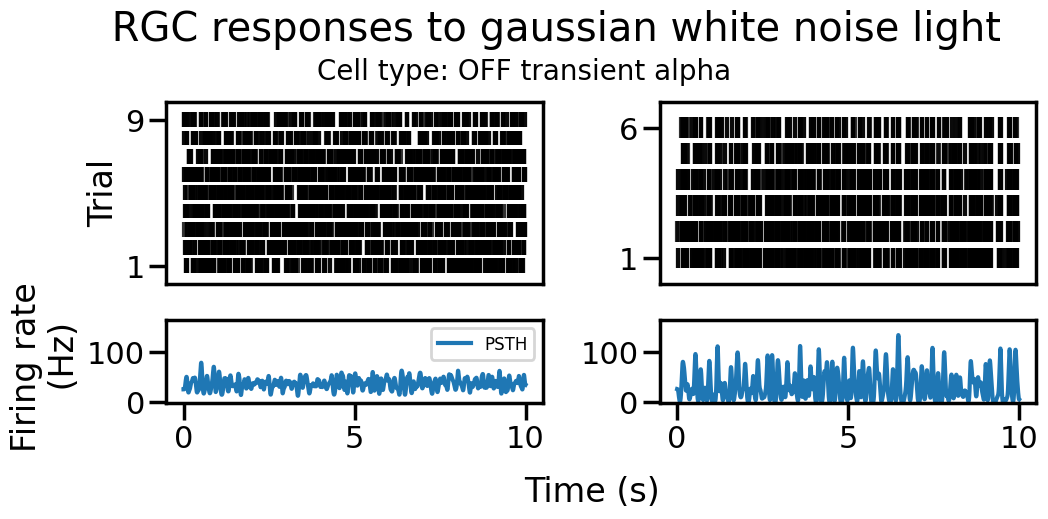

##################################################
Processing cell: 040325Bc8
train: (9, 100000) (9, 100000) mean rate (Hz): 59.32222222222222
test : (6, 100000) (6, 100000) mean rate (Hz): 58.65


/home/guardomayas/NUIN/CBEM_pytorch/utils/data_preprocessing.py:104: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


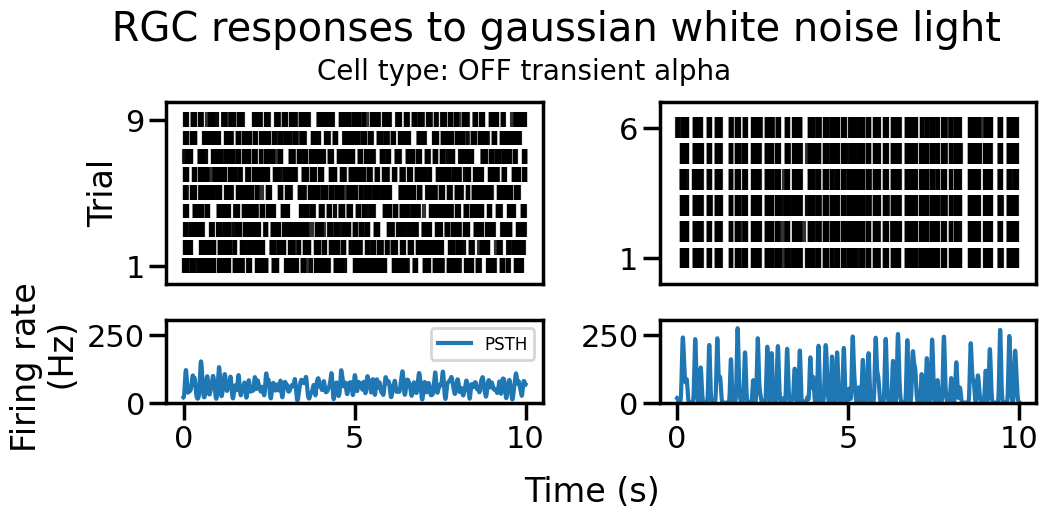

##################################################
Processing cell: 052325Bc2
train: (12, 100000) (12, 100000) mean rate (Hz): 18.358333333333334
test : (7, 100000) (7, 100000) mean rate (Hz): 18.47142857142857


/home/guardomayas/NUIN/CBEM_pytorch/utils/data_preprocessing.py:104: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


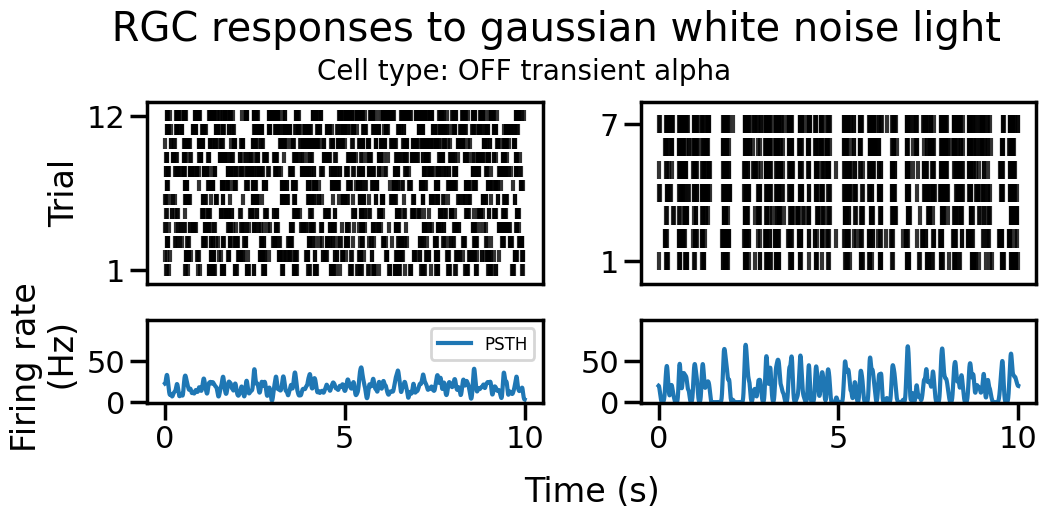

##################################################
Processing cell: 061225Bc5
train: (9, 100000) (9, 100000) mean rate (Hz): 14.588888888888889
test : (6, 100000) (6, 100000) mean rate (Hz): 15.366666666666665


/home/guardomayas/NUIN/CBEM_pytorch/utils/data_preprocessing.py:104: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


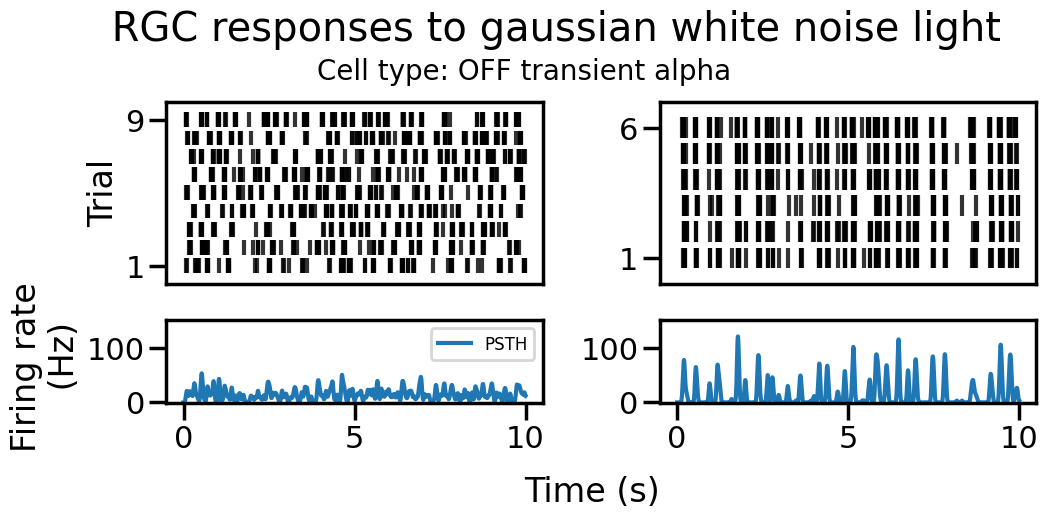

In [ ]:
data = pd.read_hdf("Data/TemporalNoise1f_v2.h5", key='data')
frame_rate = 60
dt         = 1e-4
fd         = 1
dt_stim   = 1/frame_rate

### stim basis params
nLinearRFs = 10 #;     %number of stimulus basis functions
numShortSHFilts = 5#; %each is 0.4ms long - used for refractory period
nSHfilters = 7+numShortSHFilts#;%7+

nInh = 1#;
nExc = 1#

RFstart = 2e-3 #;%0?
RFend   = 150e-3#;%150e-3 or 180e-3;
b = 0.02
#####


print(f"Available cell types: {data['cell_type'].unique()}")
cell_type ='OFF transient alpha'

results = []

ctype_df = data.query(f"cell_type == '{cell_type}' and beta == 0").copy().reset_index(drop=True)

print(f"Number of cells of celltype {cell_type}: ", ctype_df['cell_name'].nunique())

for cell_name in ctype_df['cell_name'].unique():
    print("#"*50)
    print(f"Processing cell: {cell_name}")
    cell_df = ctype_df.query(f"cell_name == '{cell_name}'").reset_index(drop=True)
    quadrant = cell_df['quadrant'][0]
    spot_size = cell_df['aperture'][0]
    # now beta is always 0
    data_beta0 = cell_df.reset_index(drop=True)

    # -------- training & test sets (once per cell) --------
    stim_mat = np.stack(data_beta0.loc[data_beta0.noise_seed != 1, 'stimulus'])
    stim_rs = np.stack(data_beta0.loc[data_beta0.noise_seed == 1, 'stimulus'])
    spk_t = np.array(data_beta0.loc[data_beta0.noise_seed != 1, 'spike_times'].tolist(), dtype=object)
    spktimes_rs = np.array(data_beta0.loc[data_beta0.noise_seed == 1, 'spike_times'].tolist(), dtype=object)

    # --- pre process---- ##
    trial_dur_s = stim_mat.shape[1] * dt_stim
    T_bins = int(round(trial_dur_s / dt))
    bin_edges_s = np.arange(T_bins + 1) * dt
        
    presamples, postsamples = None, None 
    stimulus, spk_train = preprocess_split(stim_mat, spk_t, 
                                        presamples=presamples, postsamples=postsamples, 
                                        n_trials=len(spk_t), 
                                        T_cell_full=T_bins, dt_stim=dt_stim, dt=dt, bin_edges_s=bin_edges_s)
    stimulus_test, spk_test = preprocess_split(stim_rs, spktimes_rs, 
                                            presamples=presamples, postsamples=postsamples, 
                                            n_trials=len(spktimes_rs), 
                                            T_cell_full=T_bins, dt_stim=dt_stim, dt=dt, bin_edges_s=bin_edges_s)

    print('train:', stimulus.shape, spk_train.shape, 'mean rate (Hz):', spk_train.mean() / dt)
    print('test :', stimulus_test.shape, spk_test.shape, 'mean rate (Hz):', spk_test.mean() / dt)

    # spk_train: [B, T]
    spkTimes_bins = [np.where(spk_train[trial] > 0)[0] for trial in range(spk_train.shape[0])]

    # in ms (since dt_ms is ms/bin)
    spkTimes_by_trial = [idx * dt for idx in spkTimes_bins]

    spk_idx_trials = [
        torch.as_tensor(np.where(spk_train[b] > 0)[0], device=device, dtype=torch.long)
        for b in range(spk_train.shape[0])
    ]

    spk_idx_test = [
        torch.as_tensor(np.where(spk_test[b] > 0)[0], device=device, dtype=torch.long)
        for b in range(spk_test.shape[0])
    ]
    
    sigma = max(1, int(0.02 / dt)) #psth smoothing window 

    spk_t_s_test  = [idx.detach().cpu().numpy() * dt for idx in spk_idx_test  ]  # list of arrays (sec)
    spk_t_s_train = [idx.detach().cpu().numpy() * dt for idx in spk_idx_trials]

    B, T = spk_test.shape
    B_tr, _ = spk_train.shape

    t_sec = np.arange(T) * dt

    psth_hz = gaussian_filter1d(spk_test.mean(axis=0) / dt, sigma=sigma)  
    psth_train = gaussian_filter1d(spk_train.mean(axis=0) / dt, sigma=sigma)
    fig = plot_responses(spk_t_s_train, 
                   spk_t_s_test, 
                   psth_hz, 
                   psth_train,
                   cell_type, 
                   dt, B, B_tr, T
                   )
    
    ### Design Matrix
    t, B_orth, B_raw = makeRaisedCosBasis(nLinearRFs, dt, [RFstart, RFend], b, zflag=0)
    stimulus_t = torch.as_tensor(stimulus, dtype=torch.float64, device=device)
    B_orth_t   = torch.as_tensor(B_orth,   dtype=torch.float64, device=device)

    print(stimulus_t.shape, B_orth_t.shape)
    
    X_trials = [
    convolveStimulusWithBasis_torch(stimulus_t[b], B_orth_t, add_ones=True)  # -> [T, P+1]
    for b in range(stimulus_t.shape[0])
    ]
    X_full = torch.stack(X_trials, dim=0)  # [B,T,D]
    
    linmodel = CBEM_linear(binsize_s=dt).to(device)
    cbem_lin, (steps_hist, loss_hist) = train_cbem_trials(
        linmodel,
        X_cond=X_full,
        basis_matrix= B_orth_t,
        spkTimes_bins=spk_idx_trials,
        lr=1e-1,
        conductance_penalty=None,
        n_steps=500,
        print_every=100,
        clip_grad_norm=1.0,
        window_size=None,  # or e.g. 20000
    )
    B_cond_lin = cbem_lin.B_cond.detach().cpu()